In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ['KERAS_BACKEND'] = 'tensorflow'
from keras.models import Sequential
from keras.layers import Dense, LSTM, Flatten, Conv2D
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold

2026-08-08 17:35:20.313396: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-08 17:35:20.448675: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786206920.508702   11363 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786206920.525099   11363 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-08 17:35:20.641006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# Set font type to Arial
plt.rcParams['font.family'] = 'Arial'

In [3]:
def LongShortTermMemoryModel(L1=160, L2=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L2, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def Perceptron(L1=160):

    model = Sequential()
    model.add(Flatten(input_shape=(8, 20)))
    model.add(Dense(L1))
    model.add(Dense(L1))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

def CNN(L1=160):
    model = Sequential()
    # Add a Conv2D layer with filters that convolve along the height (8) while preserving the width (20)
    model.add(Conv2D(L1, (8, 1), activation='relu', input_shape=(8, 20, 1)))
    # Flatten the output to feed into Dense layers
    model.add(Flatten())
    # Output layer with a single unit for continuous output
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

In [4]:
def AA_hotencoding(variant):
    
    """
    
    AA_hotencoding takes an amino acid sequence 'variant' of an arbitrary length, 
    and returns a 20xlength one-hot encoding matrix 'onehot_encoded'.   
    
    """
       
    AAs = 'ARNDCQEGHILKMFPSTWYV'
    encoding_length = len(AAs)
    variant_length = len(variant)

    # Define a mapping of chars to integers
    char_to_int = dict((c, i) for i, c in enumerate(AAs))
    int_to_char = dict((i, c) for i, c in enumerate(AAs))

    # Encode input data 
    integer_encoded = [char_to_int[char] for i, char in enumerate(variant) if i <variant_length]
    
    # Start one-hot-encoding
    onehot_encoded = list()
    
    for value in integer_encoded:
        letter = [0 for _ in range(encoding_length)]
        letter[value] = 1
        onehot_encoded.append(letter)
                
    return onehot_encoded

In [5]:
import random
import math

def probabilistic_division(value: float) -> int:
    """
    Probabilistically round the a value.
    Probability of rounding up equals the fractional part.
    """

    base = math.floor(value)
    frac = value - base

    # Draw from uniform distribution on [0, 1)
    if random.random() < frac:
        return base + 1
    else:
        return base

In [ ]:
# Starting from read count to perform ablation study

# define numerator and denominator files to calculate enrichment
df_numerator = pd.read_excel("data/Excel/third_round/pre_encapsulation_variant_count.xlsx")
df_denominator = pd.read_excel("data/Excel/third_round/post_encapsulation_variant_count.xlsx")

,ID,variant,quality,variant_length,variant_count
0,V350230572L2C003R05800976762/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544
1,V350231704L3C001R03000327567/1,AGTAGAGACGCGTAGGGATCCCGTCTCGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,7541
2,V350230572L1C001R04900519270/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539
3,V350231704L3C003R01100128026/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427
4,V350231704L3C001R02300983205/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141


In [ ]:
# Calculate the sum of all integers in the column "variant_count"
total_variant_count_denominator = df_denominator['variant_count'].sum()
total_variant_count_numerator = df_numerator['variant_count'].sum()

# merging both dataframes
merged_df = pd.merge(df_denominator, df_numerator, on='variant', suffixes=('_denominator', '_numerator'))

,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544
1,V350230572L2C005R01800167223/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,17385,V350230572L1C001R04900519270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539
2,V350230572L2C004R03100753574/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,14307,V350231704L3C003R01100128026/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427
3,V350230572L1C003R05500568788/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,5328,V350231704L3C001R02300983205/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141
4,V350230572L1C002R04701161624/1,AGTAGAGACGCGTAGGGATCCCGTCTCGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,5036,V350231704L3C001R03000327567/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,7541


In [8]:
# Introduce read count cutoff
merged_df = merged_df.loc[merged_df["variant_count_denominator"] >= 32]
merged_df = merged_df.loc[merged_df["variant_count_numerator"] >= 32]

In [9]:
read_count_divisors = [1, 20, 40, 60, 80, 100]

for read_count_divisor in read_count_divisors:

    # Normalize the "variant_count" column
    merged_df[f"variant_count_denominator_{read_count_divisor}"] = merged_df.apply(
    lambda row: probabilistic_division(row["variant_count_denominator"]/read_count_divisor), axis=1)
    merged_df[f"variant_count_numerator_{read_count_divisor}"] = merged_df.apply(
    lambda row: probabilistic_division(row["variant_count_numerator"]/read_count_divisor), axis=1)
    merged_df[f'variant_count_denominator_{read_count_divisor}_normalized'] = merged_df[f"variant_count_denominator_{read_count_divisor}"] / total_variant_count_denominator
    merged_df[f'variant_count_numerator_{read_count_divisor}_normalized'] = merged_df[f"variant_count_numerator_{read_count_divisor}"] / total_variant_count_numerator

    # Create a new column for the division result
    merged_df[f'enrichment_score_{read_count_divisor}'] = merged_df[f'variant_count_numerator_{read_count_divisor}_normalized'] / merged_df[f'variant_count_denominator_{read_count_divisor}_normalized']

    

In [10]:
for read_count_divisor in read_count_divisors:
    # log2 transform the enrichment score for each read count divisor
    merged_df[f'log2_enrichment_score_{read_count_divisor}'] = merged_df[f'enrichment_score_{read_count_divisor}'].apply(lambda x: np.log2(x))

/tmp/ipykernel_11363/464991768.py:3: RuntimeWarning: divide by zero encountered in log2
  merged_df[f'log2_enrichment_score_{read_count_divisor}'] = merged_df[f'enrichment_score_{read_count_divisor}'].apply(lambda x: np.log2(x))
/tmp/ipykernel_11363/464991768.py:3: RuntimeWarning: divide by zero encountered in log2
  merged_df[f'log2_enrichment_score_{read_count_divisor}'] = merged_df[f'enrichment_score_{read_count_divisor}'].apply(lambda x: np.log2(x))
/tmp/ipykernel_11363/464991768.py:3: RuntimeWarning: divide by zero encountered in log2
  merged_df[f'log2_enrichment_score_{read_count_divisor}'] = merged_df[f'enrichment_score_{read_count_divisor}'].apply(lambda x: np.log2(x))
/tmp/ipykernel_11363/464991768.py:3: RuntimeWarning: divide by zero encountered in log2
  merged_df[f'log2_enrichment_score_{read_count_divisor}'] = merged_df[f'enrichment_score_{read_count_divisor}'].apply(lambda x: np.log2(x))


In [11]:
import pandas as pd
import glob
from Bio.Seq import Seq

# Function to translate DNA sequence to amino acid sequence
def translate_dna_to_protein(dna_seq):
    dna_seq_obj = Seq(dna_seq)
    protein_seq = str(dna_seq_obj.translate())
    return protein_seq

# Translate the 'variant' column and save in a new column 'amino_acid_sequence'
merged_df['amino_acid_sequence'] = merged_df['variant'].apply(translate_dna_to_protein)

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [ ]:
# Get rid of variants with stop codons
merged_df = merged_df[~merged_df.astype(str).apply(lambda row: row.str.contains(r"\*").any(), axis=1)]
merged_df = merged_df.loc[merged_df["variant_length_denominator"]==24]


# Remove rational designs from the dataset
rational_motifs = ["YP*L", "PP*Y", "FPIV", "PLPPV", "L**L", "KFERQ", "PSAP", "PTAP"]

import re

# Function to check if sequence contains any of the motifs
def contains_motifs(sequence, motifs):
    return any(motif for motif in motifs if contains_wildcard_motif(sequence, motif))

def contains_wildcard_motif(sequence, motif):
    # Convert the motif to a regex pattern, replacing '*' with '.'
    regex_pattern = motif.replace("*", ".")
    # Search for the pattern in the sequence
    return re.search(regex_pattern, sequence) is not None

merged_df = merged_df[~merged_df['amino_acid_sequence'].apply(lambda seq: contains_motifs(seq, rational_motifs))]

,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_1,...,variant_count_denominator_100_normalized,variant_count_numerator_100_normalized,enrichment_score_100,log2_enrichment_score_1,log2_enrichment_score_20,log2_enrichment_score_40,log2_enrichment_score_60,log2_enrichment_score_80,log2_enrichment_score_100,amino_acid_sequence
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544,58563,...,1.350392e-04,1.534882e-05,0.113662,-3.130292,-3.131476,-3.134815,-3.138657,-3.134815,-3.137178,LRGDVGGP
5,V350230572L1C004R05700108921/1,AGGCGGGCGGATACTTGTAGTGCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4796,V350230572L1C001R04800561978/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,696,4796,...,1.108014e-05,1.432557e-06,0.129290,-2.958377,-2.993132,-2.993132,-2.910670,-2.886422,-2.951312,RRADTCSA
6,V350230572L2C003R03701213307/1,CATAAGGAGCATTGTGCTACGAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4449,V350231704L3C003R02301264686/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,543,4449,...,1.038763e-05,1.023255e-06,0.098507,-3.208161,-3.219717,-3.267680,-3.232598,-3.370101,-3.343629,HKEHCATS
8,V350230572L1C002R07100567629/1,ACTGCGCCTGGGGTTCATTGTGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,3297,V350230572L1C001R04201058623/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,733,3297,...,7.617595e-06,1.637208e-06,0.214924,-2.342973,-2.361331,-2.283329,-2.370101,-2.361331,-2.218098,TAPGVHCG
10,V350230572L2C004R02300026454/1,AGGTGTGTTGATCAGAAGGTTTCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,3172,V350231704L3C002R00501383900/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,389,3172,...,7.386759e-06,6.139528e-07,0.083115,-3.201255,-3.238660,-3.155557,-3.289181,-3.173704,-3.588742,RCVDQKVS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19982,V350230572L1C005R02901262072/1,TCTATTCACCACTGGTACATTTTG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350231704L3C002R01900419625/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,42,32,...,0.000000e+00,2.046509e-07,inf,0.218613,-0.173704,-0.173704,inf,-0.173704,inf,SIHHWYIL
19999,V350230572L2C003R00100347010/1,ACTATTCACCACGTTTACCCTATT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350230572L2C002R01800983226/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,49,32,...,0.000000e+00,0.000000e+00,NaN,0.441006,1.411258,-0.173704,-inf,-inf,NaN,TIHHVYPI
20010,V350230572L1C002R01201377885/1,CATGTGCACCACCCGTACCTTCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350231704L3C001R05800057540/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,39,32,...,0.000000e+00,0.000000e+00,NaN,0.111698,-0.173704,-0.173704,inf,-inf,NaN,HVHHPYLP
20025,V350230572L2C005R01700967496/1,TCTAAGCACCACATTTACAATAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,32,V350230572L2C002R00900670455/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,35,32,...,2.308362e-07,0.000000e+00,0.000000,-0.044421,-0.173704,inf,-0.173704,inf,-inf,SKHHIYNS


In [ ]:
models = {}

for read_count_divisor in read_count_divisors:
    # Perform cross-validation for each model
        models[f'FNN_{read_count_divisor}'] = [Perceptron,read_count_divisor]
        models[f'LSTM_{read_count_divisor}'] = [LongShortTermMemoryModel,read_count_divisor]
        models[f'CNN_{read_count_divisor}'] = [CNN,read_count_divisor]

pearson_results = {model_name: [] for model_name in models.keys()}

{'FNN_1': [], 'LSTM_1': [], 'CNN_1': [], 'FNN_20': [], 'LSTM_20': [], 'CNN_20': [], 'FNN_40': [], 'LSTM_40': [], 'CNN_40': [], 'FNN_60': [], 'LSTM_60': [], 'CNN_60': [], 'FNN_80': [], 'LSTM_80': [], 'CNN_80': [], 'FNN_100': [], 'LSTM_100': [], 'CNN_100': []}
{'FNN_1': [<function Perceptron at 0x7f1dc3f62160>, 1], 'LSTM_1': [<function LongShortTermMemoryModel at 0x7f1e42d93c40>, 1], 'CNN_1': [<function CNN at 0x7f1dc291bce0>, 1], 'FNN_20': [<function Perceptron at 0x7f1dc3f62160>, 20], 'LSTM_20': [<function LongShortTermMemoryModel at 0x7f1e42d93c40>, 20], 'CNN_20': [<function CNN at 0x7f1dc291bce0>, 20], 'FNN_40': [<function Perceptron at 0x7f1dc3f62160>, 40], 'LSTM_40': [<function LongShortTermMemoryModel at 0x7f1e42d93c40>, 40], 'CNN_40': [<function CNN at 0x7f1dc291bce0>, 40], 'FNN_60': [<function Perceptron at 0x7f1dc3f62160>, 60], 'LSTM_60': [<function LongShortTermMemoryModel at 0x7f1e42d93c40>, 60], 'CNN_60': [<function CNN at 0x7f1dc291bce0>, 60], 'FNN_80': [<function Perceptro

In [14]:
# Define the number of folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for model_name, model_params in models.items():
    model_func = model_params[0]
    read_count_divisor = model_params[1]

    fold = 1
    fold_results = []

    print("length of dataframe",len(merged_df))

    snapshot_df = merged_df.copy()

    snapshot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    snapshot_df = snapshot_df.dropna(subset=[f'log2_enrichment_score_{read_count_divisor}'])

    # GOAL train test split
    # 80% training, 10% validation, 10% test
    train_size = 0.8 * len(snapshot_df)
    test_size = 0.1 * len(snapshot_df)

    # Split the data into training and test sets
    train, test = np.split(snapshot_df.sample(frac=1), [int(train_size)])
  
    # GOAL one hot encoding of the amino acid sequences

    train_x = np.asarray([AA_hotencoding(variant) for variant in train["amino_acid_sequence"]])
    train_y = np.asarray([score for score in train[f'log2_enrichment_score_{read_count_divisor}']])
    test_x = np.asarray([AA_hotencoding(variant) for variant in test["amino_acid_sequence"]])
    test_y = np.asarray([score for score in test[f'log2_enrichment_score_{read_count_divisor}']])

    train_y_current = train_y
    
    for train_index, val_index in kf.split(train_x):
            print(f"Training fold {fold} for {model_name}...")
            
            # Split the data into training and validation sets
            X_train, X_val = train_x[train_index], train_x[val_index]
            y_train, y_val = train_y_current[train_index], train_y_current[val_index]
            
            # Create the model
            model = model_func()
            
            # Train the model
            model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=500,
                verbose=0
            )
            
            # Evaluate the model on the validation set
            val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)

            # Store the results for the current model
            y_pred = model.predict(X_val)
            y_pred = np.reshape(y_pred, (1,y_pred.shape[0]))[0]
            pearson_corr = np.corrcoef(y_val, y_pred)[0, 1]
            pearson_results[model_name].append(pearson_corr)
            print(f"Pearson for {model_name} {fold}: {pearson_results[model_name]}")
            
            fold += 1

length of dataframe 1835
Training fold 1 for FNN_1...


/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1786207009.491306   11363 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Pearson for FNN_1 1: [0.6500271558511118]
Training fold 2 for FNN_1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Pearson for FNN_1 2: [0.6500271558511118, 0.676771665414333]
Training fold 3 for FNN_1...
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f1dac11b1a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Pearson for LSTM_1 1: [0.60183131502157]
Training fold 2 for LSTM_1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Pearson for LSTM_1 2: [0.60183131502157, 0.4773900791576427]
Training fold 3 for LSTM_1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Pearson for LSTM_1 3: [0.60183131502157, 0.4773900791576427, 0.7536761296984678]
Training fold 4 for LSTM_1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Pearson for LSTM_1 4: [0.60183131502157, 0.4773900791576427, 0.7536761296984678, 0.7104853645929148]
Training fold 5 for LSTM_1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Pearson for LSTM_1 5: [0.60183131502157, 0.4773900791576427, 0.7536761296984678, 0.7104853645929148, 0.6411094384191551]
Training fold 6 for LSTM_1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Pearson for LSTM_1 6: [0.60183131502157, 0.4773900791576427, 0.7536761296984678, 0.7104853645929148, 0.6411094384191551, 0.737107262048511]
Training fold 7 for LSTM_1...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Pearson f

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Pearson for FNN_100 1: [0.47197841118043615]
Training fold 2 for FNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Pearson for FNN_100 2: [0.47197841118043615, 0.6542795616622198]
Training fold 3 for FNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Pearson for FNN_100 3: [0.47197841118043615, 0.6542795616622198, 0.26198740196555753]
Training fold 4 for FNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Pearson for FNN_100 4: [0.47197841118043615, 0.6542795616622198, 0.26198740196555753, 0.45196638492949687]
Training fold 5 for FNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Pearson for FNN_100 5: [0.47197841118043615, 0.6542795616622198, 0.26198740196555753, 0.45196638492949687, 0.3765755400733658]
Training fold 6 for FNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Pearson for FNN_100 6: [0.47197841118043615, 0.6542795616622198, 0.26198740196555753, 0.45196638492949687, 0.3765755400733658, 0.4302100641628579]
Training fold 7 for FNN_100...
3/3 ━━━━━

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Pearson for LSTM_100 1: [0.6783244848351059]
Training fold 2 for LSTM_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Pearson for LSTM_100 2: [0.6783244848351059, 0.32287030914563064]
Training fold 3 for LSTM_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Pearson for LSTM_100 3: [0.6783244848351059, 0.32287030914563064, 0.5068617218856162]
Training fold 4 for LSTM_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Pearson for LSTM_100 4: [0.6783244848351059, 0.32287030914563064, 0.5068617218856162, 0.6667332574543053]
Training fold 5 for LSTM_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Pearson for LSTM_100 5: [0.6783244848351059, 0.32287030914563064, 0.5068617218856162, 0.6667332574543053, 0.5763409311914974]
Training fold 6 for LSTM_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Pearson for LSTM_100 6: [0.6783244848351059, 0.32287030914563064, 0.5068617218856162, 0.6667332574543053, 0.5763409311914974, 0.5049195452366936]
Training fold 7 for LSTM_100...
3/3 ━

/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/home/marinaluchner/anaconda3/envs/modelling_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Pearson for CNN_100 1: [0.5387372948173739]
Training fold 2 for CNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Pearson for CNN_100 2: [0.5387372948173739, 0.5899414003101233]
Training fold 3 for CNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Pearson for CNN_100 3: [0.5387372948173739, 0.5899414003101233, 0.4519291371577658]
Training fold 4 for CNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Pearson for CNN_100 4: [0.5387372948173739, 0.5899414003101233, 0.4519291371577658, 0.45713459522046024]
Training fold 5 for CNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Pearson for CNN_100 5: [0.5387372948173739, 0.5899414003101233, 0.4519291371577658, 0.45713459522046024, 0.5305729764969759]
Training fold 6 for CNN_100...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Pearson for CNN_100 6: [0.5387372948173739, 0.5899414003101233, 0.4519291371577658, 0.45713459522046024, 0.5305729764969759, 0.5773659427919376]
Training fold 7 for CNN_100...
3/3 ━━━━━━━━━━━━━━━

In [16]:
# Define the number of folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# GOAL: Train a Linear Regression model to predict the log2_averaged_enrichment_score from the one-hot encoded amino acid sequences
for read_count_divisor in read_count_divisors:

    snapshot_df = merged_df.copy()

    snapshot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    snapshot_df = snapshot_df.dropna(subset=[f'log2_enrichment_score_{read_count_divisor}'])

    train_x = np.asarray([AA_hotencoding(variant) for variant in snapshot_df["amino_acid_sequence"]])
    train_y = np.asarray([score for score in snapshot_df[f'log2_enrichment_score_{read_count_divisor}']])

    train_y_current = train_y
    fold_results = []
    fold = 1
    
    for train_index, val_index in kf.split(train_x):
        print(f"Training fold {fold}...")
        
        # Split the data into training and validation sets
        X_train, X_val = train_x[train_index], train_x[val_index]
        y_train, y_val = train_y_current[train_index], train_y_current[val_index]

        # Reshape the 3D arrays into 2D arrays
        X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
        X_val_reshaped = X_val.reshape(X_val.shape[0], -1)
        
        # Train the model
        model = LinearRegression()
        model.fit(X_train_reshaped, y_train)
        y_pred = model.predict(X_val_reshaped)

        # Calculate pearson correlation coefficient
        corrcoef = np.corrcoef(y_val, y_pred)[0, 1]
        print(f"Pearson for LR_{read_count_divisor} fold {fold}: {corrcoef}")
        # Append the results to the fold_results list
        fold_results.append(corrcoef)
        fold += 1

    pearson_results[f'LR_{read_count_divisor}'] = fold_results    

Training fold 1...
Pearson for LR_1 fold 1: 0.6001895773482742
Training fold 2...
Pearson for LR_1 fold 2: 0.6600617425489067
Training fold 3...
Pearson for LR_1 fold 3: 0.43635303033460465
Training fold 4...
Pearson for LR_1 fold 4: 0.6543776665017489
Training fold 5...
Pearson for LR_1 fold 5: 0.5674756403293351
Training fold 6...
Pearson for LR_1 fold 6: 0.541456550792318
Training fold 7...
Pearson for LR_1 fold 7: 0.5558929905682541
Training fold 8...
Pearson for LR_1 fold 8: 0.20866362688763784
Training fold 9...
Pearson for LR_1 fold 9: 0.702343593992076
Training fold 10...
Pearson for LR_1 fold 10: 0.6239443161810875
Training fold 1...
Pearson for LR_20 fold 1: 0.49324281055525493
Training fold 2...
Pearson for LR_20 fold 2: 0.6092892315786833
Training fold 3...
Pearson for LR_20 fold 3: 0.3986019354480624
Training fold 4...
Pearson for LR_20 fold 4: 0.579204496673836
Training fold 5...
Pearson for LR_20 fold 5: 0.5137545365213668
Training fold 6...
Pearson for LR_20 fold 6: 0.4

In [18]:
# Set font properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24

In [ ]:
from statistics import mean

averages = {
    key: mean(values)
    for key, values in pearson_results.items()
}
errors = {
    key: np.std(values)
    for key, values in pearson_results.items()
}

from collections import defaultdict

model_results = defaultdict(list)

model_errors = defaultdict(list)

for key, avg in averages.items():
    model, threshold = key.split("_")
    model_results[model].append((threshold, avg))

for key, error in errors.items():
    model, threshold = key.split("_")
    model_errors[model].append((threshold, error))

final = {}
final_errors = {}

for model, values in model_results.items():
    values.sort(key=lambda x: x[0])        # sort by threshold
    final[model] = [avg for _, avg in values]

for model, values in model_errors.items():
    values.sort(key=lambda x: x[0])        # sort by threshold
    final_errors[model] = [error for _, error in values]

final_lists = {k: [v for v in vals] for k, vals in final.items()}
final_error_lists = {k: [v for v in vals] for k, vals in final_errors.items()}

{'FNN_1': 0.6204324371243857, 'LSTM_1': 0.6421333916844149, 'CNN_1': 0.6396635815120237, 'FNN_20': 0.5610861891594476, 'LSTM_20': 0.6093165098235708, 'CNN_20': 0.5543027203227239, 'FNN_40': 0.4930960958313913, 'LSTM_40': 0.5628619930541142, 'CNN_40': 0.5605767351326381, 'FNN_60': 0.4867109892458415, 'LSTM_60': 0.6076033543492348, 'CNN_60': 0.5491547139451756, 'FNN_80': 0.4063804555768084, 'LSTM_80': 0.5676658391658103, 'CNN_80': 0.49945901900654227, 'FNN_100': 0.47294360706681454, 'LSTM_100': 0.5532179881390222, 'CNN_100': 0.5290428997678361, 'LR_1': 0.5550758735484242, 'LR_20': 0.4979666747617773, 'LR_40': 0.44199912906803207, 'LR_60': 0.4727651327709478, 'LR_80': 0.40190921609446273, 'LR_100': 0.4324207949019532}
defaultdict(<class 'list'>, {'FNN': [('1', 0.6204324371243857), ('20', 0.5610861891594476), ('40', 0.4930960958313913), ('60', 0.4867109892458415), ('80', 0.4063804555768084), ('100', 0.47294360706681454)], 'LSTM': [('1', 0.6421333916844149), ('20', 0.6093165098235708), ('40

[1, 20, 40, 60, 80, 100]
[0.5550758735484242, 0.4324207949019532, 0.4979666747617773, 0.44199912906803207, 0.4727651327709478, 0.40190921609446273]
[1, 20, 40, 60, 80, 100]
[0.6204324371243857, 0.47294360706681454, 0.5610861891594476, 0.4930960958313913, 0.4867109892458415, 0.4063804555768084]
[1, 20, 40, 60, 80, 100]
[0.6396635815120237, 0.5290428997678361, 0.5543027203227239, 0.5605767351326381, 0.5491547139451756, 0.49945901900654227]
[1, 20, 40, 60, 80, 100]
[0.6421333916844149, 0.5532179881390222, 0.6093165098235708, 0.5628619930541142, 0.6076033543492348, 0.5676658391658103]


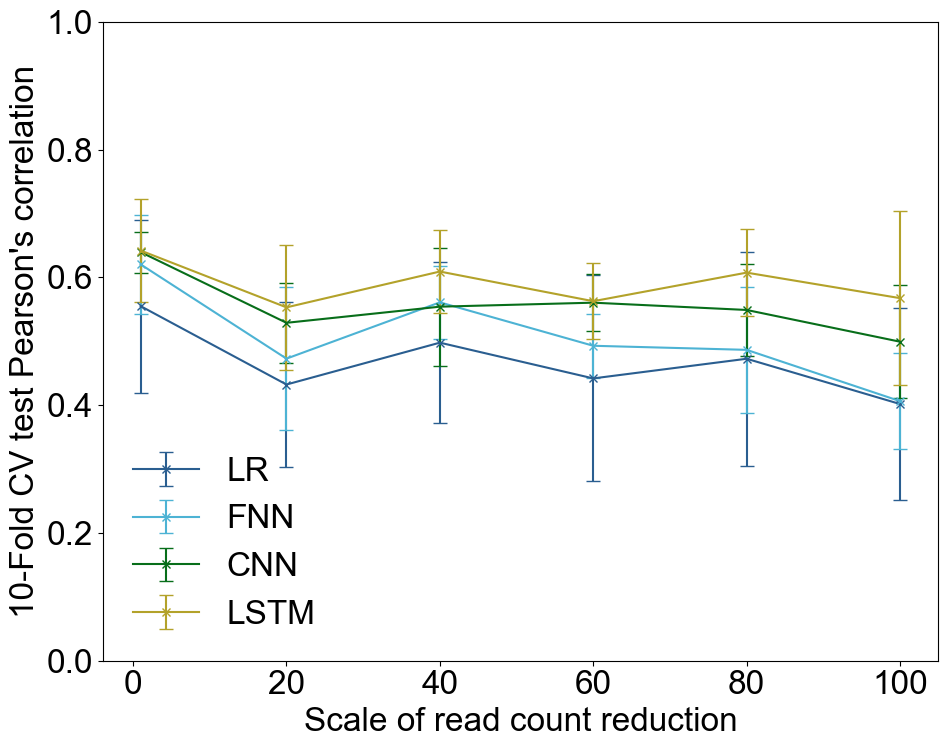

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Paul Tol's Notes color scheme
colors = ['#4477AA','#66CCEE','#228833','#CCBB44','#EE6677','#AA3377','#BBBBBB']

# Function to darken a color
def darken_color(color, amount=0.1):
    c = mcolors.to_rgb(color)
    return mcolors.to_hex([max(0, c[i] - amount) for i in range(3)])

darker_colors = [darken_color(color) for color in colors]

# Create scatter plot

plt.figure(figsize=(10, 8))

j = 0

model_order = ["LR", "FNN", "CNN", "LSTM"]

# Plot average Pearson correlation coefficients
for model_name in model_order:
    plt.errorbar(
        read_count_divisors, 
        final_lists[model_name], 
        color=darker_colors[j],
        yerr=final_error_lists[model_name],
        capsize=5,
        marker='x',  
        label=f'{model_name}'
    )
    j += 1

# Customize plot
plt.ylabel("10-Fold CV test Pearson's correlation", fontsize=24)
plt.xlabel('Scale of read count reduction', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.ylim(0, 1)

# Create custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='black', markerfacecolor='black', markersize=7, label='Individual'),
    plt.Line2D([0], [0], marker='x', color='black', markersize=7, label='Average')
]

# Show plot
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('plots/figure_4c.png')
plt.show()